<a href="https://colab.research.google.com/github/Sanyukta10-09/Weather-App/blob/main/IntelliWeather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
os.environ["OWM_API_KEY"] = "d2c8a986b9e6d81d8e7fc211e84ee802"

In [16]:
!pip install requests reportlab matplotlib pandas ipywidgets --quiet

In [17]:
import csv, io, os, re, subprocess, sys, warnings
from datetime import datetime, timedelta
from typing import Dict, List, Optional, Tuple

import ipywidgets as widgets
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import requests
from IPython.display import display, clear_output, HTML, Image as IPImage

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    Image as RLImage, HRFlowable
)

warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

API_KEY  = os.environ.get("OWM_API_KEY")
BASE_URL = "https://api.openweathermap.org/data/2.5"
OUT_DIR  = "/content"

if not API_KEY:
    print("WARNING: API key not found. Run Cell 0 first.")
else:
    print("Environment ready.")

Environment ready.


In [18]:
def deg_to_compass(deg: float) -> str:
    labels = ["N","NNE","NE","ENE","E","ESE","SE","SSE",
              "S","SSW","SW","WSW","W","WNW","NW","NNW"]
    return labels[int((deg / 22.5) + 0.5) % 16]


def fetch_current(location: str) -> Optional[Dict]:
    try:
        r = requests.get(
            f"{BASE_URL}/weather",
            params={"q": location, "appid": API_KEY, "units": "metric"},
            timeout=10
        )
        r.raise_for_status()
        return r.json()
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error fetching current weather: {e}")
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
    return None


def fetch_forecast(location: str) -> Optional[Dict]:
    try:
        r = requests.get(
            f"{BASE_URL}/forecast",
            params={"q": location, "appid": API_KEY, "units": "metric", "cnt": 40},
            timeout=10
        )
        r.raise_for_status()
        return r.json()
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error fetching forecast: {e}")
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
    return None

print("Fetching helpers ready.")

Fetching helpers ready.


In [19]:
def build_current_rows(data: Dict) -> List[Dict]:
    m    = data.get('main', {})
    wind = data.get('wind', {})
    vis  = data.get('visibility')
    cond = (data.get('weather') or [{}])[0].get('description', 'N/A').title()

    vis_str = 'N/A'
    if isinstance(vis, (int, float)):
        vis_str = f"{vis/1000:.1f} km" if vis >= 1000 else f"{vis} m"

    wind_str = 'N/A'
    if wind:
        spd     = wind.get('speed', 'N/A')
        deg     = wind.get('deg')
        compass = deg_to_compass(deg) if isinstance(deg, (int, float)) else ''
        wind_str = f"{spd} m/s {compass}".strip()

    return [
        {"Attribute": "Date / Time",  "Value": datetime.fromtimestamp(data['dt']).strftime('%d %b %Y, %I:%M %p') if data.get('dt') else 'N/A'},
        {"Attribute": "Temperature",  "Value": f"{m.get('temp', 'N/A')} C"},
        {"Attribute": "Feels Like",   "Value": f"{m.get('feels_like', 'N/A')} C"},
        {"Attribute": "Condition",    "Value": cond},
        {"Attribute": "Wind",         "Value": wind_str},
        {"Attribute": "Pressure",     "Value": f"{m.get('pressure', 'N/A')} hPa"},
        {"Attribute": "Humidity",     "Value": f"{m.get('humidity', 'N/A')}%"},
        {"Attribute": "Visibility",   "Value": vis_str},
    ]


def build_daily_summary(forecast: Dict) -> List[Dict]:
    daily = {}
    for entry in forecast.get('list', []):
        try:
            dt     = datetime.strptime(entry['dt_txt'], '%Y-%m-%d %H:%M:%S')
            key    = dt.strftime('%Y-%m-%d')
            temp   = entry.get('main', {}).get('temp')
            desc   = (entry.get('weather') or [{}])[0].get('description', '').title()
            precip = entry.get('rain', {}).get('3h', 0) + entry.get('snow', {}).get('3h', 0)
            if key not in daily:
                daily[key] = {'high': float('-inf'), 'low': float('inf'), 'conditions': set(), 'precip': 0.0}
            if temp is not None:
                daily[key]['high'] = max(daily[key]['high'], temp)
                daily[key]['low']  = min(daily[key]['low'],  temp)
            if desc:
                daily[key]['conditions'].add(desc)
            daily[key]['precip'] += precip
        except (ValueError, KeyError, TypeError):
            continue

    rows = []
    for date_str in sorted(daily)[:5]:
        d = daily[date_str]
        rows.append({
            "Date":        datetime.strptime(date_str, '%Y-%m-%d').strftime('%a, %d %b'),
            "High (C)":    f"{d['high']:.1f}" if d['high'] != float('-inf') else 'N/A',
            "Low (C)":     f"{d['low']:.1f}"  if d['low']  != float('inf')  else 'N/A',
            "Precip (mm)": f"{d['precip']:.1f}",
            "Conditions":  ", ".join(sorted(d['conditions'])) or 'N/A',
        })
    return rows


def parse_question(question: str) -> Dict:
    loc_match = re.search(r'\bin\s+([A-Za-z][A-Za-z\s,]{1,40})', question, re.IGNORECASE)
    location  = loc_match.group(1).strip().title() if loc_match else None
    target    = datetime.now() + timedelta(days=1) if 'tomorrow' in question.lower() else datetime.now()
    condition = None
    for kw, label in [('rain','rain'),('snow','snow'),('sun','sun'),
                      ('temp','temperature'),('wind','wind'),('humid','humidity')]:
        if kw in question.lower():
            condition = label
            break
    return {'location': location, 'date': target.strftime('%Y-%m-%d'), 'condition': condition}


def generate_summary(current: Optional[Dict], forecast: Optional[Dict],
                     location: str, condition: Optional[str]) -> str:
    parts = []
    if current and current.get('main'):
        m    = current['main']
        desc = (current.get('weather') or [{}])[0].get('description', '').lower()
        parts.append(f"Currently in {location}: {m.get('temp', 'N/A')} C, {desc}.")
        parts.append(f"Humidity {m.get('humidity', 'N/A')}%, pressure {m.get('pressure', 'N/A')} hPa.")
    if forecast and forecast.get('list'):
        nxt = forecast['list'][0]
        t   = nxt.get('main', {}).get('temp', 'N/A')
        d   = (nxt.get('weather') or [{}])[0].get('description', '').lower()
        parts.append(f"In the next 3 hours: {d}, around {t} C.")
        if condition in ('rain', 'snow'):
            found   = any(condition in (e.get('weather') or [{}])[0].get('description','').lower() for e in forecast['list'])
            verdict = "is expected" if found else "is not expected"
            parts.append(f"{condition.capitalize()} {verdict} over the next 5 days.")
    return ' '.join(parts) if parts else f"No weather data available for {location}."

print("Analysis functions ready.")

Analysis functions ready.


In [20]:
def _forecast_series(forecast: Dict):
    dates, highs, lows, precips = [], [], [], []
    for entry in forecast.get('list', []):
        try:
            dt     = datetime.strptime(entry['dt_txt'], '%Y-%m-%d %H:%M:%S')
            m      = entry.get('main', {})
            precip = entry.get('rain', {}).get('3h', 0) + entry.get('snow', {}).get('3h', 0)
            dates.append(dt)
            highs.append(m.get('temp_max'))
            lows.append(m.get('temp_min'))
            precips.append(precip)
        except (ValueError, KeyError):
            continue
    return dates, highs, lows, precips


def chart_temperature(forecast: Dict, location: str) -> bytes:
    dates, highs, lows, _ = _forecast_series(forecast)
    valid = [(d, h, l) for d, h, l in zip(dates, highs, lows) if h is not None and l is not None]
    if not valid:
        return b''
    dv, hv, lv = zip(*valid)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(dv, hv, color='#C0392B', lw=1.5, marker='o', ms=3, label='High')
    ax.plot(dv, lv, color='#2980B9', lw=1.5, marker='o', ms=3, label='Low')
    ax.fill_between(dv, hv, lv, alpha=0.08, color='#7F8C8D')
    ax.set_title(f"Temperature Forecast — {location.title()}", fontsize=11, pad=8)
    ax.set_ylabel('Temperature (C)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Hh'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
    plt.xticks(rotation=35, ha='right', fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130)
    plt.close(fig)
    buf.seek(0)
    return buf.read()


def chart_precipitation(forecast: Dict, location: str) -> bytes:
    dates, _, _, precips = _forecast_series(forecast)
    if not dates:
        return b''

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.bar(dates, precips, width=0.09, color='#5DADE2', edgecolor='none')
    ax.set_title(f"Precipitation Forecast — {location.title()}", fontsize=11, pad=8)
    ax.set_ylabel('Precipitation (mm / 3 h)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.xticks(rotation=35, ha='right', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130)
    plt.close(fig)
    buf.seek(0)
    return buf.read()

print("Chart helpers ready.")

Chart helpers ready.


In [21]:
def _rl_image(png_bytes: bytes, width_cm: float = 15) -> Optional[RLImage]:
    if not png_bytes:
        return None
    img = RLImage(io.BytesIO(png_bytes), width=width_cm * cm)
    img.hAlign = 'LEFT'
    return img


def build_pdf(location: str, summary: str, current_rows: List[Dict],
              daily_rows: List[Dict], temp_png: bytes, precip_png: bytes) -> str:

    safe  = re.sub(r'[^\w]', '_', location.lower())
    stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    path  = os.path.join(OUT_DIR, f"weatherwise_{safe}_{stamp}.pdf")

    doc = SimpleDocTemplate(path, pagesize=A4,
                            leftMargin=2*cm, rightMargin=2*cm,
                            topMargin=2*cm, bottomMargin=2*cm)
    bs  = getSampleStyleSheet()
    H1  = ParagraphStyle('H1',  parent=bs['Heading1'], fontSize=16, spaceAfter=4,  textColor=colors.HexColor('#1A252F'))
    H2  = ParagraphStyle('H2',  parent=bs['Heading2'], fontSize=11, spaceAfter=4,  textColor=colors.HexColor('#2C3E50'))
    SUB = ParagraphStyle('Sub', parent=bs['Normal'],   fontSize=8,  textColor=colors.HexColor('#7F8C8D'))
    BOD = ParagraphStyle('Bod', parent=bs['Normal'],   fontSize=9.5, leading=14)

    hdr_bg = colors.HexColor('#2C3E50')
    alt_bg = colors.HexColor('#F2F3F4')
    TS = [
        ('BACKGROUND',    (0,0),(-1,0), hdr_bg),
        ('TEXTCOLOR',     (0,0),(-1,0), colors.white),
        ('FONTNAME',      (0,0),(-1,0), 'Helvetica-Bold'),
        ('FONTSIZE',      (0,0),(-1,-1), 8.5),
        ('ROWBACKGROUNDS',(0,1),(-1,-1), [colors.white, alt_bg]),
        ('GRID',          (0,0),(-1,-1), 0.3, colors.HexColor('#D5D8DC')),
        ('LEFTPADDING',   (0,0),(-1,-1), 6),
        ('RIGHTPADDING',  (0,0),(-1,-1), 6),
        ('TOPPADDING',    (0,0),(-1,-1), 4),
        ('BOTTOMPADDING', (0,0),(-1,-1), 4),
        ('VALIGN',        (0,0),(-1,-1), 'MIDDLE'),
    ]

    story = []
    story.append(Paragraph(f"WeatherWise Report — {location.title()}", H1))
    story.append(Paragraph(f"Generated {datetime.now().strftime('%d %B %Y at %H:%M')}", SUB))
    story.append(HRFlowable(width='100%', thickness=0.5, color=colors.HexColor('#AAB7B8'), spaceAfter=8))

    story.append(Paragraph("Summary", H2))
    story.append(Paragraph(summary, BOD))
    story.append(Spacer(1, 0.4*cm))

    if current_rows:
        story.append(Paragraph("Current Conditions", H2))
        data = [["Attribute", "Value"]] + [[r["Attribute"], r["Value"]] for r in current_rows]
        tbl  = Table(data, colWidths=[5*cm, 10*cm])
        tbl.setStyle(TableStyle(TS))
        story.append(tbl)
        story.append(Spacer(1, 0.5*cm))

    img = _rl_image(temp_png)
    if img:
        story.append(Paragraph("Temperature Forecast", H2))
        story.append(img)
        story.append(Spacer(1, 0.4*cm))

    img = _rl_image(precip_png)
    if img:
        story.append(Paragraph("Precipitation Forecast", H2))
        story.append(img)
        story.append(Spacer(1, 0.4*cm))

    if daily_rows:
        story.append(Paragraph("5-Day Summary", H2))
        headers = list(daily_rows[0].keys())
        data    = [headers] + [[row[h] for h in headers] for row in daily_rows]
        col_w   = [3*cm, 2.2*cm, 2.2*cm, 2.5*cm, 6.1*cm]
        tbl     = Table(data, colWidths=col_w)
        tbl.setStyle(TableStyle(TS))
        story.append(tbl)

    story.append(Spacer(1, 0.6*cm))
    story.append(HRFlowable(width='100%', thickness=0.3, color=colors.HexColor('#AAB7B8')))
    story.append(Paragraph("Data source: OpenWeatherMap API  |  WeatherWise v2", SUB))

    doc.build(story)
    return path

print("PDF builder ready.")

PDF builder ready.


In [22]:
def notify(title: str, message: str, pdf_path: str) -> None:
    sent = False
    if sys.platform.startswith('linux'):
        try:
            subprocess.run(['notify-send', title, message], check=True, timeout=5)
            sent = True
        except (FileNotFoundError, subprocess.SubprocessError):
            pass
    elif sys.platform == 'darwin':
        try:
            subprocess.run(['osascript', '-e', f'display notification "{message}" with title "{title}"'],
                           check=True, timeout=5)
            sent = True
        except (FileNotFoundError, subprocess.SubprocessError):
            pass

    color = '#1ABC9C' if sent else '#2980B9'
    display(HTML(f"""
    <div style="background:{color};color:#fff;padding:10px 16px;
                border-radius:6px;font-family:sans-serif;margin-top:8px">
      <strong>{title}</strong><br>
      {message}<br>
      <small>Saved to: <code style="color:#D5F5E3">{pdf_path}</code></small>
    </div>
    """))

print("Notification helper ready.")

Notification helper ready.


In [23]:
def export_csv(forecast: Dict, location: str) -> str:
    safe = re.sub(r'[^\w]', '_', location.lower())
    path = os.path.join(OUT_DIR, f"{safe}_forecast.csv")
    with open(path, mode='w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(['Datetime', 'Temp (C)', 'High (C)', 'Low (C)', 'Condition', 'Precip (mm)'])
        for entry in forecast.get('list', []):
            m      = entry.get('main', {})
            precip = entry.get('rain', {}).get('3h', 0) + entry.get('snow', {}).get('3h', 0)
            w.writerow([
                entry.get('dt_txt', 'N/A'),
                m.get('temp', 'N/A'), m.get('temp_max', 'N/A'), m.get('temp_min', 'N/A'),
                (entry.get('weather') or [{}])[0].get('description', 'N/A'),
                precip,
            ])
    return path

print("CSV export ready.")

CSV export ready.


In [24]:
def run_weatherwise(location_query: str, specific_question: str = '') -> None:
    print(f"Fetching data for '{location_query}' ...")

    parsed    = parse_question(specific_question) if specific_question else {}
    location  = parsed.get('location') or location_query
    condition = parsed.get('condition')

    current  = fetch_current(location)
    forecast = fetch_forecast(location)

    if not current and not forecast:
        print(f"No data returned for '{location}'. Check the city name and your API key.")
        return

    current_rows = build_current_rows(current) if current else []
    daily_rows   = build_daily_summary(forecast) if forecast else []
    summary      = generate_summary(current, forecast, location, condition)

    print("\n" + "=" * 60)
    print(f"  WeatherWise — {location.title()}")
    print("=" * 60)
    print(f"\nSummary\n{summary}\n")

    if current_rows:
        df = pd.DataFrame(current_rows).set_index('Attribute')
        print("Current Conditions")
        print(df.to_string())
        print()

    if daily_rows:
        df = pd.DataFrame(daily_rows)
        print("5-Day Forecast Summary")
        print(df.to_string(index=False))
        print()

    temp_png   = chart_temperature(forecast, location)  if forecast else b''
    precip_png = chart_precipitation(forecast, location) if forecast else b''

    for png, label in [(temp_png, 'Temperature forecast'), (precip_png, 'Precipitation forecast')]:
        if png:
            display(HTML(f"<p style='font-weight:500;margin-top:1rem'>{label}</p>"))
            display(IPImage(data=png))

    if forecast:
        csv_path = export_csv(forecast, location)
        print(f"\nRaw forecast CSV: {csv_path}")

    print("Building PDF report ...")
    pdf_path = build_pdf(
        location=location, summary=summary,
        current_rows=current_rows, daily_rows=daily_rows,
        temp_png=temp_png, precip_png=precip_png,
    )

    notify(
        title    = "WeatherWise — Report Ready",
        message  = f"PDF analysis for {location.title()} is ready.",
        pdf_path = pdf_path,
    )

    try:
        from google.colab import files
        files.download(pdf_path)
    except Exception:
        pass

print("Pipeline ready.")

Pipeline ready.


Enter a city: Port Louis
Ask a question (or press Enter to skip): 
Fetching data for 'Port Louis' ...

  WeatherWise — Port Louis

Summary
Currently in Port Louis: 23.01 C, light rain. Humidity 86%, pressure 1022 hPa. In the next 3 hours: light rain, around 23.01 C.

Current Conditions
                             Value
Attribute                         
Date / Time  15 Jun 2026, 05:41 PM
Temperature                23.01 C
Feels Like                 23.61 C
Condition               Light Rain
Wind                   5.89 m/s SE
Pressure                  1022 hPa
Humidity                       86%
Visibility                 10.0 km

5-Day Forecast Summary
       Date High (C) Low (C) Precip (mm)            Conditions
Mon, 15 Jun     23.3    23.0         1.0            Light Rain
Tue, 16 Jun     25.3    23.3         0.8 Clear Sky, Light Rain
Wed, 17 Jun     24.1    23.0         2.1 Clear Sky, Light Rain
Thu, 18 Jun     23.6    22.5         0.0             Clear Sky
Fri, 19 Jun     23.3    

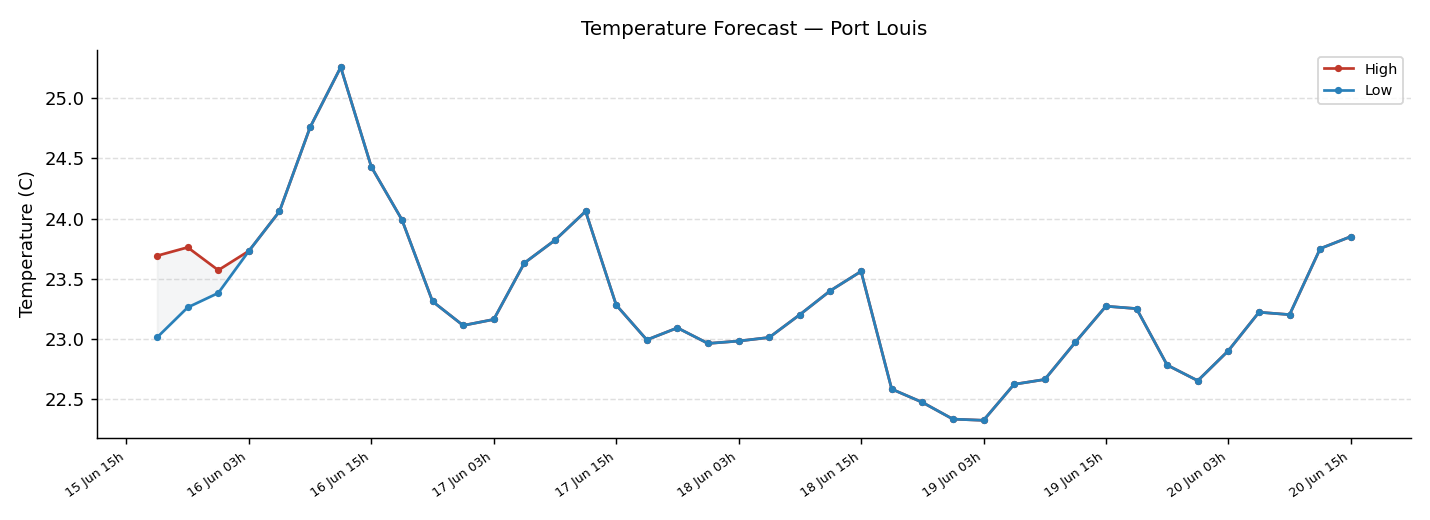

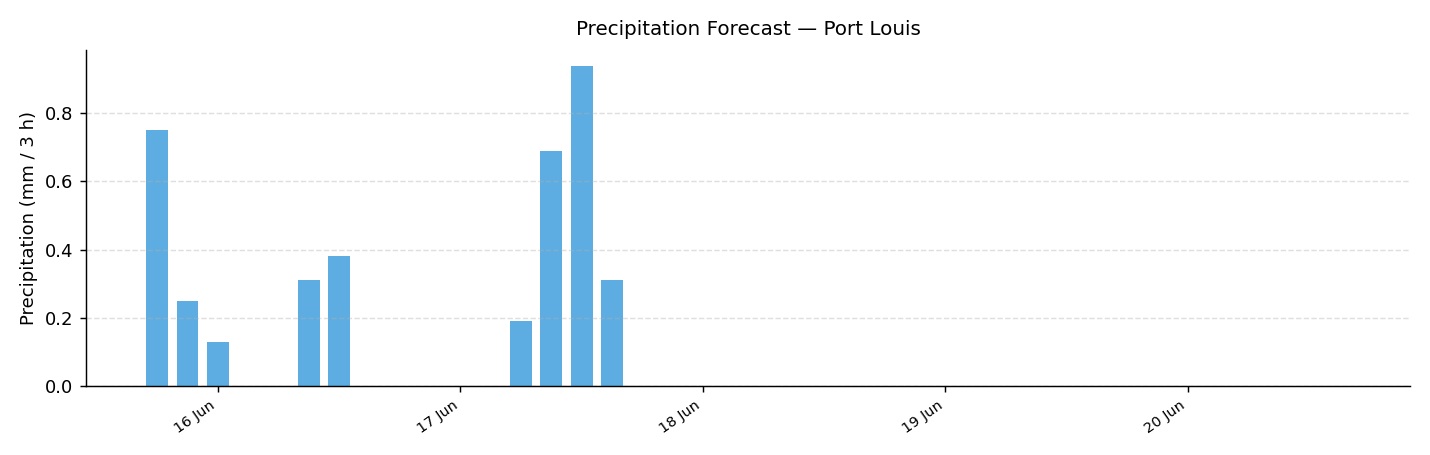


Raw forecast CSV: /content/port_louis_forecast.csv
Building PDF report ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
location = input("Enter a city: ")
question = input("Ask a question (or press Enter to skip): ")

run_weatherwise(
    location_query    = location,
    specific_question = question
)